In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tftinsights
import tftinsights.data

In [44]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, RegressorMixin
import os

def baseline_score(model, x_test, y_test):
    preds = model.predict(x_test)
    return mean_squared_error(y_test, preds)
    
def train_and_evaluate_model(
    model,
    x_train, y_train,
    x_val, y_val,
    x_test, y_test,
    save_path='saved_model/best_model',
    epochs=15,
    batch_size=32
):

    
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    x_test = scaler.transform(x_test)

    class R2Callback(tf.keras.callbacks.Callback):
        def __init__(self, validation_data, save_path):
            self.validation_data = validation_data
            self.best_r2 = -np.inf
            self.save_path = save_path

        def on_epoch_end(self, epoch, logs=None):
            x_val, y_val = self.validation_data
            y_pred = self.model.predict(x_val, verbose=0)
            r2 = r2_score(y_val, y_pred)

            if logs is not None:
                logs['val_r2'] = r2

            print(f"Epoch {epoch + 1}: val_R2 = {r2:.4f}")

            if r2 > self.best_r2:
                os.makedirs(os.path.dirname(self.save_path), exist_ok=True)
                self.best_r2 = r2
                self.model.save(self.save_path)
                print(f"New best R² ({r2:.4f}) — model saved.")

    # Compile and train model
    r2_callback = R2Callback(validation_data=(x_val, y_val), save_path=save_path)
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[r2_callback]
    )

    best_epoch = np.argmax(history.history['val_r2']) + 1
    best_r2 = max(history.history['val_r2'])
    print(f"\nBest R²: {best_r2:.4f} at epoch {best_epoch}")
    
    best_model = tf.keras.models.load_model(save_path)

    test_loss, test_mae = best_model.evaluate(x_test, y_test)
    y_pred = best_model.predict(x_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)

    print(f"\nTest MAE: {test_mae:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test R² Score: {test_r2:.4f}\n")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.ylim(bottom=0)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['val_r2'], label='val_r2')
    plt.title("Validation R² Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("R² Score")
    plt.ylim(bottom=0)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return

Epoch 1: val_R2 = 0.5581
New best R² (0.5581) — model saved.
Epoch 2: val_R2 = 0.5864
New best R² (0.5864) — model saved.
Epoch 3: val_R2 = 0.6087
New best R² (0.6087) — model saved.
Epoch 4: val_R2 = 0.6159
New best R² (0.6159) — model saved.
Epoch 5: val_R2 = 0.6126
Epoch 6: val_R2 = 0.6171
New best R² (0.6171) — model saved.
Epoch 7: val_R2 = 0.6235
New best R² (0.6235) — model saved.
Epoch 8: val_R2 = 0.6119
Epoch 9: val_R2 = 0.6072
Epoch 10: val_R2 = 0.6145
Epoch 11: val_R2 = 0.5951
Epoch 12: val_R2 = 0.5859
Epoch 13: val_R2 = 0.5821
Epoch 14: val_R2 = 0.5884
Epoch 15: val_R2 = 0.5869

Best R²: 0.6235 at epoch 7
428/428 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - loss: 1.8930 - mae: 1.0811
428/428 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step

Test MAE: 1.0972
Test MSE: 1.9450
Test R² Score: 0.6318



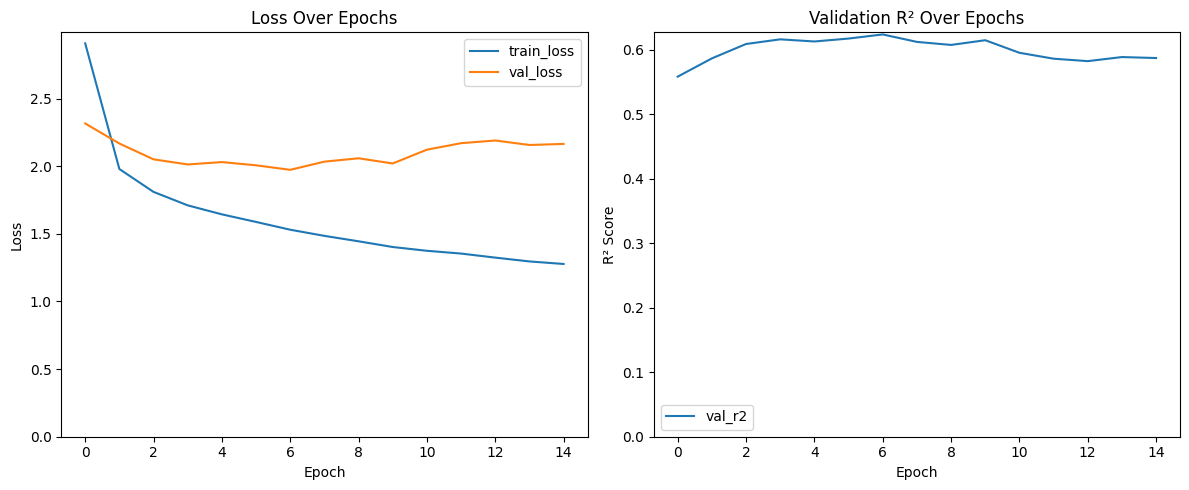


Calculating permutation feature importance...

Top Feature Importances:
Feature 220: Importance = 0.370609
Feature 250: Importance = 0.317306
Feature 228: Importance = 0.269276
Feature 197: Importance = 0.262705
Feature 205: Importance = 0.251252
Feature 196: Importance = 0.251020
Feature 212: Importance = 0.249749
Feature 252: Importance = 0.213130
Feature 232: Importance = 0.207652
Feature 199: Importance = 0.206085


In [45]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

df = tftinsights.data.get_tft_dataset(include_traits  =True, include_units =True, include_items=True,include_engineered_features=True,include_player_data=False)  
y = df['placement'].astype(float) #dependent variable
x = df.drop(columns='placement') #independent variables 

x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

train_and_evaluate_model(
    model=model,
    x_train=x_train, y_train=y_train,
    x_val=x_val, y_val=y_val,
    x_test=x_test, y_test=y_test,
    save_path='saved_model/my_best_model.keras'
)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam

df = tftinsights.data.get_tft_dataset(include_traits  =False, include_units =False, include_items=False,include_engineered_features=True,include_player_data=False)  
y = df['placement'].astype(float) #dependent variable
x = df.drop(columns='placement') #independent variables 

x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=42)

# Define your model
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(), loss='mse', metrics=['mae'])

# Call the function
train_and_evaluate_model(
    model=model,
    x_train=x_train, y_train=y_train,
    x_val=x_val, y_val=y_val,
    x_test=x_test, y_test=y_test,
    save_path='saved_model/my_best_model.keras'
)